In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/data/nutrient_mineral_dataset.csv")
df.sample(10)

,nutrient_deficiency,symptoms,recommended_foods,recommended_beverages
4456,Selenium,"fatigue, muscle weakness, brain fog","eggs, sunflower seeds, brown rice",smoothie
3499,Magnesium,"weakness, fatigue, anxiety","banana, pumpkin seeds",green smoothie
1879,Vitamin E,"poor balance, numbness, dry skin","hazelnut, avocado",soy milk
4566,Selenium,"fatigue, brain fog, hair loss, weak immunity","eggs, brazil nuts",protein shake
2259,Vitamin K,"slow clotting, bleeding gums","broccoli, lettuce",vegetable juice
1222,Vitamin D,"fatigue, depression, back pain","salmon, mushroom, cheese",soy milk
1264,Vitamin D,"muscle weakness, back pain, depression, bone pain","egg yolk, mushroom, salmon",fortified juice
4208,Potassium,"muscle weakness, fatigue, cramps, constipation","avocado, orange, potato",orange juice
1560,Vitamin D,"depression, back pain, fatigue","salmon, milk, egg yolk",fortified juice
4674,Selenium,"weak immunity, fatigue","eggs, sunflower seeds, brazil nuts",milk


<Axes: xlabel='count', ylabel='nutrient_deficiency'>

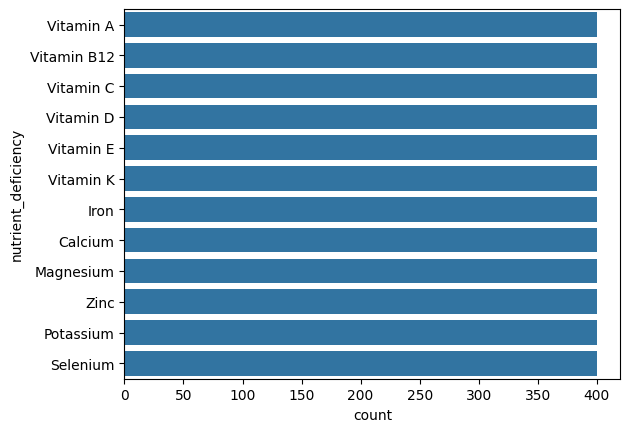

In [3]:
sns.countplot(df['nutrient_deficiency'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   nutrient_deficiency    4800 non-null   object
 1   symptoms               4800 non-null   object
 2   recommended_foods      4800 non-null   object
 3   recommended_beverages  4800 non-null   object
dtypes: object(4)
memory usage: 150.1+ KB


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

X = df["symptoms"]
y = df["nutrient_deficiency"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline
text_model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000))
])

text_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', LogisticRegression(max_iter=1000))])

In [13]:
symptoms = "muscle weakness"

In [14]:
predicted_deficiency = text_model.predict([symptoms])[0]
print("Predicted Nutrient Deficiency:", predicted_deficiency)

Predicted Nutrient Deficiency: Vitamin E


In [10]:
import pickle

with open("text_model.pkl", "wb") as file:
  pickle.dump(text_model, file)